In [1]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt 

from basisbench.models.taylor import Taylor

In [58]:
lr = 0.1
epochs = 2000

train_losses = []
val_losses = []

model = Taylor(degree=10)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

train_df = pd.read_csv('C:\\Users\\User\\Desktop\\basisbench\\data\\proccessed\\train_set.csv')
val_df = pd.read_csv('C:\\Users\\User\\Desktop\\basisbench\\data\\proccessed\\val_set.csv')
test_df = pd.read_csv('C:\\Users\\User\\Desktop\\basisbench\\data\\proccessed\\test_set.csv')

x_train, y_train = train_df['timenormalized'], train_df['norm_cnt']
x_val, y_val = val_df['timenormalized'], val_df['norm_cnt']
x_test, y_test = test_df['timenormalized'], test_df['norm_cnt']

x_train = torch.tensor(x_train.to_numpy(), dtype=torch.float32)
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float32)

x_val = torch.tensor(x_val.to_numpy(), dtype=torch.float32)
y_val = torch.tensor(y_val.to_numpy(), dtype=torch.float32)

x_test = torch.tensor(x_test.to_numpy(), dtype=torch.float32)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

for epoch in range(epochs):
    #* kill previuos gradients
    optimizer.zero_grad()
    
    #* forward pass
    model.train()
    predictions = model(x_train)
    train_loss = loss_fn(predictions, y_train)
    
    #* backward pass
    train_loss.backward()
    # print('Coefficient magniture: ')
    # print(model.coefficients.detach().abs())
    
    #* update parametes
    optimizer.step()
    # print('Coefficient magniture: ')
    # print(model.coefficients.detach().abs())
    
    train_losses.append(train_loss.item())
    
    #* validation
    model.eval()
    
    with torch.no_grad():
        val_predicitions = model(x_val)
        val_loss = loss_fn(val_predicitions, y_val)
        
    val_losses.append(val_loss)
            
    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss.item():.6f} | "
            f"Val Loss: {val_loss.item():.6f}"
        )
    

Epoch    0 | Train Loss: 0.999365 | Val Loss: 2.758061
Epoch  100 | Train Loss: 0.928091 | Val Loss: 2.349263
Epoch  200 | Train Loss: 0.925130 | Val Loss: 2.289095
Epoch  300 | Train Loss: 0.922623 | Val Loss: 2.247700
Epoch  400 | Train Loss: 0.920438 | Val Loss: 2.217810
Epoch  500 | Train Loss: 0.918494 | Val Loss: 2.196224
Epoch  600 | Train Loss: 0.916736 | Val Loss: 2.181015
Epoch  700 | Train Loss: 0.915122 | Val Loss: 2.170832
Epoch  800 | Train Loss: 0.913625 | Val Loss: 2.164672
Epoch  900 | Train Loss: 0.912224 | Val Loss: 2.161771
Epoch 1000 | Train Loss: 0.910903 | Val Loss: 2.161544
Epoch 1100 | Train Loss: 0.909653 | Val Loss: 2.163535
Epoch 1200 | Train Loss: 0.908465 | Val Loss: 2.167389
Epoch 1300 | Train Loss: 0.907333 | Val Loss: 2.172826
Epoch 1400 | Train Loss: 0.906252 | Val Loss: 2.179621
Epoch 1500 | Train Loss: 0.905218 | Val Loss: 2.187596
Epoch 1600 | Train Loss: 0.904229 | Val Loss: 2.196605
Epoch 1700 | Train Loss: 0.903280 | Val Loss: 2.206528
Epoch 1800

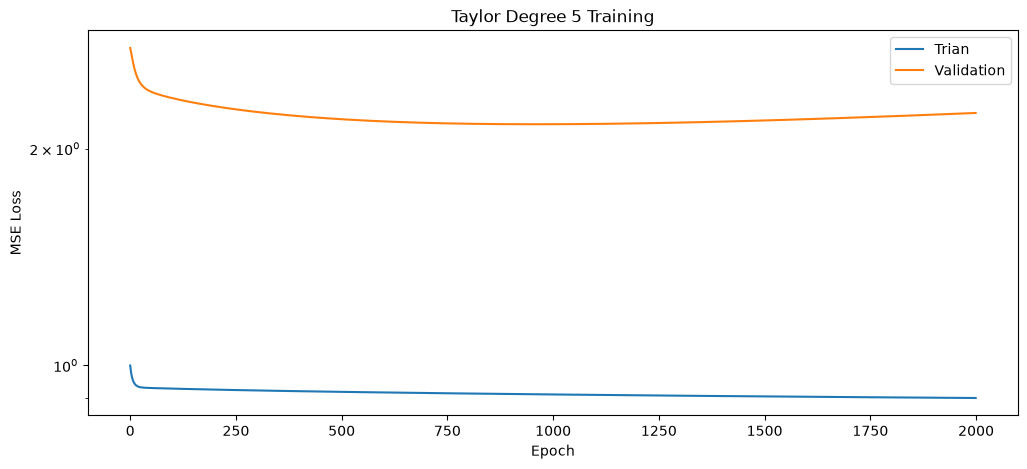

In [68]:
plt.figure(figsize=(12,5))

plt.plot(train_losses, label='Trian')
plt.plot(val_losses, label='Validation')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log')
plt.title("Taylor Degree 5 Training")

plt.legend()
plt.show()

In [66]:
model.eval()

with torch.no_grad():
    val_pred_scaled = model(x_val)
    test_pred_scaled = model(x_test)
    
train_mean = train_df['cnt'].mean()
train_std = train_df['cnt'].std()

val_pred = (
    val_pred_scaled.numpy() * train_std + train_mean
)

test_pred = (
    test_pred_scaled.numpy() * train_std + train_mean
)

val_actual = val_df['cnt'].to_numpy()
test_actual = test_df['cnt'].to_numpy()
val_actual, test_actual

(array([ 61,  36,  11, ..., 278, 318, 509], shape=(2607,)),
 array([925, 977, 635, ...,  90,  61,  49], shape=(2607,)))

In [67]:
from basisbench.evaluation.metrics import (
    mean_absolute_error,
    mean_square_error,
    root_mean_squared_error
)

print("Taylor degree 5")
print("\nValidation")
print("MAE :", mean_absolute_error(val_actual, val_pred))
print("RMSE:", root_mean_squared_error(val_actual, val_pred))
print("MSE :", mean_square_error(val_actual, val_pred))

print("\nTest")
print("MAE :", mean_absolute_error(test_actual, test_pred))
print("RMSE:", root_mean_squared_error(test_actual, test_pred))
print("MSE :", mean_square_error(test_actual, test_pred))

Taylor degree 5

Validation
MAE : 189.30190365155485
RMSE: 228.39701514978165
MSE : 52165.19652932959

Test
MAE : 329.5983804278011
RMSE: 372.58732143696704
MSE : 138821.31209557378


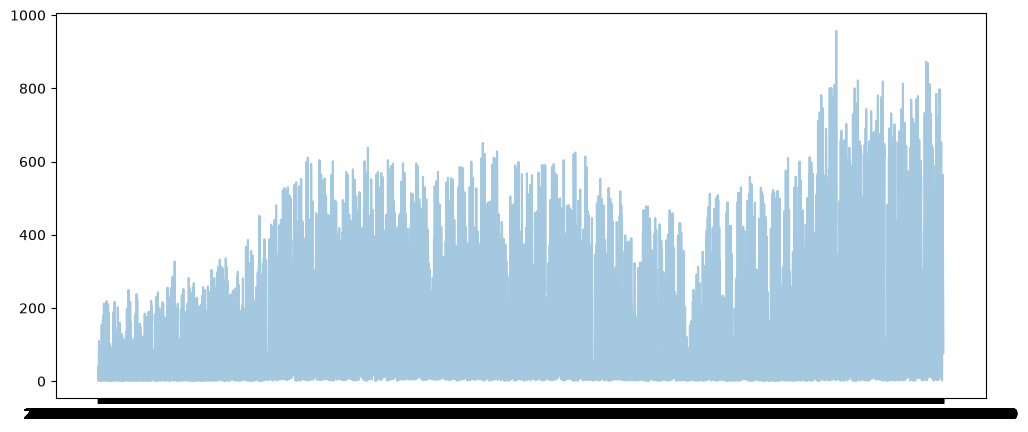

In [69]:
plt.figure(figsize=(12,5))

plt.plot(
    train_df['datetime'],
    train_df['cnt'],
    label='Actual',
    alpha=0.4
)